# S&P 500 Options: Feature Engineering

This notebook generates the feature matrix for the S&P 500 Options case study.
Features are organized into three groups:

1. **Instrument state** -- straddle mid, Greeks, DTE, relative spread
2. **Surface features** -- IV level, skew, term structure, VRP, dynamics
3. **Quality features** -- convergence codes, staleness proxies

**Learning Objectives**:
- Construct instrument-specific features from straddle Greeks and prices
- Compute VRP (IV - RV) with trailing z-score and cross-sectional normalization
- Separate instrument features from surface summary features
- Build cross-sectional rank features for relative value

**Book Reference**: Chapter 8, Section 8.3 (Structural and Cross-Instrument Features)

**Prerequisites**: [`01_feasibility_analysis`](01_feasibility_analysis.ipynb) (trading setup), [`02_labels`](02_labels.ipynb) (labels)

In [1]:
"""S&P 500 Options: Feature Engineering - Instrument + Surface Features."""

import subprocess
import warnings
from datetime import UTC, datetime

import numpy as np
import polars as pl
import yaml

from case_studies.sp500_options._underlying_returns import reconcile_underlying_log_returns
from data import load_sp500_daily_bars, load_sp500_options_straddles
from utils.paths import get_case_study_dir
from utils.style import COLORS, ml4t_diverging  # registers the ml4t Plotly template on import

warnings.filterwarnings("ignore")

In [2]:
# Scale parameters (Papermill overrides for testing; readers see production values)
START_DATE = None  # None = use full dataset

In [3]:
CASE_DIR = get_case_study_dir("sp500_options")
FEATURES_DIR = CASE_DIR / "features"
LABELS_DIR = CASE_DIR / "labels"

STRATEGY_ID = "sp500_options"
INSTRUMENT_ID = "straddle_30d_atm"

## 1. Load Instrument Prices and Underlying

Pre-materialized 30D ATM straddles with straddle-level data: mid/bid/ask,
ATM IV, aggregated Greeks (delta, gamma, theta, vega), DTE, relative spread,
and quality flags for each (symbol, date) pair. Underlying daily bars provide
split-adjusted returns and realized volatility for VRP computation. Raw closes
remain available for same-date price-level calculations.

In [4]:
def attach_security_identity(straddle_df: pl.DataFrame, prices_df: pl.DataFrame) -> pl.DataFrame:
    """Attach the unique contemporaneous security identity to each straddle."""
    identity = prices_df.select("timestamp", "symbol", "sec_id")
    duplicate_keys = identity.group_by("timestamp", "symbol").len().filter(pl.col("len") != 1)
    if duplicate_keys.height:
        raise ValueError(
            "Underlying identity map is not unique on (timestamp, symbol): "
            f"{duplicate_keys.height} duplicate keys"
        )
    if identity["sec_id"].null_count():
        raise ValueError("Underlying identity map contains null sec_id values")

    joined = straddle_df.join(
        identity,
        on=["timestamp", "symbol"],
        how="left",
        validate="m:1",
    )
    if joined["sec_id"].null_count():
        raise ValueError(
            "Straddle rows lack contemporaneous security identity: "
            f"{joined['sec_id'].null_count()} unmapped rows"
        )
    return joined.sort(["symbol", "sec_id", "timestamp"])

In [5]:
straddles = load_sp500_options_straddles()

# Load underlying for RV computation and attach its stable security identity.
underlying = load_sp500_daily_bars()
straddles = attach_security_identity(straddles, underlying)

print(f"Loaded straddle instruments with security identity: {straddles.shape}")
print(f"Underlying: {underlying.shape[0]:,} rows, {underlying['symbol'].n_unique()} symbols")

Loaded straddle instruments with security identity: (361010, 45)
Underlying: 635,703 rows, 638 symbols


## 2. Underlying Features: Returns and Realized Volatility

These provide the "RV" side of the VRP equation and basic momentum features.

In [6]:
def compute_underlying_features(prices_df: pl.DataFrame) -> pl.DataFrame:
    """Compute returns and volatility within stable security identities."""
    df = reconcile_underlying_log_returns(prices_df)
    segment = ["symbol", "sec_id"]
    return_windows = [1, 5, 10, 21]
    rv_windows = [5, 10, 21, 42, 63]
    return_exprs = [
        pl.col("clean_log_return")
        .rolling_sum(w, min_samples=w)
        .over(segment)
        .exp()
        .sub(1)
        .alias(f"ret_{w}d")
        for w in return_windows
    ]
    rv_exprs = [
        (
            pl.col("clean_log_return").rolling_std(w, min_samples=w).over(segment) * np.sqrt(252)
        ).alias(f"rv_{w}d")
        for w in rv_windows
    ]
    volume_expr = (
        (pl.col("volume") - pl.col("volume").rolling_mean(20).over(segment))
        / pl.col("volume").rolling_std(20).over(segment)
    ).alias("volume_zscore")
    df = df.with_columns(return_exprs + rv_exprs + [volume_expr])
    cols = (
        ["timestamp", "symbol", "sec_id", "close", "adjusted_close", "identity_boundary"]
        + [f"ret_{w}d" for w in return_windows]
        + [f"rv_{w}d" for w in rv_windows]
        + ["volume_zscore"]
    )
    return df.select([c for c in cols if c in df.columns])

In [7]:
underlying_feats = compute_underlying_features(underlying)
print(f"Underlying features: {underlying_feats.shape}")

Underlying features: (635703, 16)


### Corporate-Action Integrity Check

A split changes the quoted close but not the investor's economic return. The
check below independently reconstructs adjusted one-day returns and verifies
that raw split jumps do not survive in the engineered feature.

In [8]:
def audit_underlying_feature_windows(
    prices_df: pl.DataFrame, features_df: pl.DataFrame
) -> dict[str, float | int]:
    """Verify daily-return arithmetic and warmup isolation at every identity boundary."""
    segment = ["symbol", "sec_id"]
    audit = features_df.with_columns(
        pl.col("timestamp").cum_count().over(segment).alias("segment_position")
    ).join(
        reconcile_underlying_log_returns(prices_df).select(
            "timestamp", "symbol", "clean_log_return"
        ),
        on=["timestamp", "symbol"],
        how="left",
    )
    audit = audit.with_columns(
        (pl.col("ret_1d") - pl.col("clean_log_return").exp().sub(1)).abs().alias("error")
    )
    max_error = float(audit["error"].drop_nulls().max() or 0.0)
    warmup_violations = 0
    for horizon in [1, 5, 10, 21]:
        warmup_violations += audit.filter(
            (pl.col("segment_position") <= horizon) & pl.col(f"ret_{horizon}d").is_not_null()
        ).height
    boundaries = audit.filter(pl.col("identity_boundary"))
    if (
        max_error > 1e-12
        or warmup_violations
        or boundaries["ret_1d"].null_count() != len(boundaries)
    ):
        raise ValueError(
            "Security-segment return audit failed: "
            f"max error={max_error:.3e}, warmup violations={warmup_violations}"
        )
    return {
        "identity_boundaries": len(boundaries),
        "warmup_violations": warmup_violations,
        "max_identity_error": max_error,
    }

In [9]:
adjustment_audit = audit_underlying_feature_windows(underlying, underlying_feats)
print(
    "Security-identity check: "
    f"{adjustment_audit['identity_boundaries']} boundaries, "
    f"{adjustment_audit['warmup_violations']} warmup violations, "
    f"max return error {adjustment_audit['max_identity_error']:.1e}"
)

Security-identity check: 15 boundaries, 0 warmup violations, max return error 0.0e+00


Three familiar split events make the adjustment concrete: the raw quote jumps
vanish once the cumulative price factor is applied.

In [10]:
split_examples = underlying_feats.filter(
    ((pl.col("symbol") == "FAST") & (pl.col("timestamp") == pl.date(2019, 5, 23)))
    | ((pl.col("symbol") == "AAPL") & (pl.col("timestamp") == pl.date(2020, 8, 31)))
    | ((pl.col("symbol") == "NVDA") & (pl.col("timestamp") == pl.date(2021, 7, 20)))
).select("timestamp", "symbol", pl.col("ret_1d").alias("adjusted_return"))
split_examples

timestamp,symbol,adjusted_return
date,str,f64
2020-08-31,"""AAPL""",0.033912
2019-05-23,"""FAST""",-0.024891
2021-07-20,"""NVDA""",-0.008932


Security-identity changes are not returns. The first observation for the new
security, and each horizon's full warmup window, therefore remain null.

In [11]:
identity_examples = underlying_feats.filter(
    pl.col("identity_boundary") & pl.col("symbol").is_in(["DD", "DIS", "ARNC", "IR", "APA", "STX"])
).select("timestamp", "symbol", "sec_id", "ret_1d", "ret_5d", "rv_5d")
identity_examples

timestamp,symbol,sec_id,ret_1d,ret_5d,rv_5d
date,str,i64,f64,f64,f64
2021-03-02,"""APA""",6802832,null,null,null
2020-04-06,"""ARNC""",6285863,null,null,null
2019-06-03,"""DD""",5229608,null,null,null
2019-06-03,"""DIS""",5972580,null,null,null
2020-03-02,"""IR""",5122670,null,null,null
2021-05-19,"""STX""",6926831,null,null,null


## 3. Instrument State Features

These describe the straddle itself: mid price, relative spread, Greeks, DTE.
They capture the cost and risk profile of the instrument we are trading.

In [12]:
def compute_instrument_features(df: pl.DataFrame) -> pl.DataFrame:
    """Compute instrument-specific features from straddle data.

    These features describe the instrument we are actually trading.
    """
    segment = ["symbol", "sec_id"]
    df = df.sort(segment + ["timestamp"])

    df = df.with_columns(
        # Theta/vega ratio: how much time decay per unit of vol exposure
        (pl.col("instr_theta") / pl.col("instr_vega").clip(lower_bound=0.001)).alias(
            "theta_vega_ratio"
        ),
        # Straddle premium as pct of underlying
        # (already in prices as instr_pct_of_S)
        # DTE normalized to [0,1] range for comparability
        (pl.col("instr_dte") / 30.0).alias("dte_normalized"),
        # Absolute delta (should be near zero for ATM straddle)
        pl.col("instr_delta").abs().alias("abs_net_delta"),
    )

    # Lagged instrument returns (time-series momentum of straddle price)
    df = df.with_columns(
        (pl.col("instr_mid") / pl.col("instr_mid").shift(1).over(segment) - 1).alias(
            "instr_ret_1d"
        ),
        (pl.col("instr_mid") / pl.col("instr_mid").shift(5).over(segment) - 1).alias(
            "instr_ret_5d"
        ),
    )

    return df

In [13]:
straddles = compute_instrument_features(straddles)
print(f"With instrument features: {straddles.shape}")

With instrument features: (361010, 50)


## 4. Surface Features: VRP, IV Dynamics, Skew

These describe the volatility surface and risk premium. The VRP (IV - RV)
is the core signal for short vol strategies.

### 4a. VRP and IV Level Features

In [14]:
def compute_vrp_level_features(
    straddle_df: pl.DataFrame, underlying_rv: pl.DataFrame
) -> pl.DataFrame:
    """Compute VRP level features: VRP at various horizons, IV-RV ratio, IV skew."""
    rv_cols = [c for c in underlying_rv.columns if c.startswith("rv_")]
    df = straddle_df.join(
        underlying_rv.select(["timestamp", "symbol", "sec_id"] + rv_cols),
        on=["timestamp", "symbol", "sec_id"],
        how="left",
        validate="m:1",
    )

    df = df.with_columns(
        (pl.col("iv_atm") - pl.col("rv_5d")).alias("vrp_5d"),
        (pl.col("iv_atm") - pl.col("rv_10d")).alias("vrp_10d"),
        (pl.col("iv_atm") - pl.col("rv_21d")).alias("vrp_21d"),
        (pl.col("iv_atm") - pl.col("rv_42d")).alias("vrp_42d"),
        (pl.col("iv_atm") - pl.col("rv_63d")).alias("vrp_63d"),
        (pl.col("iv_atm") / pl.col("rv_21d").clip(lower_bound=0.01)).alias("iv_rv_ratio"),
        (pl.col("call_iv") - pl.col("put_iv")).alias("iv_skew_atm"),
    )

    return df

### 4b. VRP Normalization and IV Z-Scores

Normalize VRP by its own 252-day history to remove regime-level effects.
A VRP of 5% means different things in calm vs stressed markets.

**Warmup note**: The 252-day rolling window requires ~1 year of straddle data
per symbol before producing values. With options data starting in 2017, these
features become available from ~2018 onward. In production (2017-2021), they
cover the 2019-2020 test periods well. In TEST mode (single year), they will
be mostly null and are excluded from evaluation.

In [15]:
def compute_vrp_normalization(df: pl.DataFrame) -> pl.DataFrame:
    """Add trailing VRP and IV z-scores."""
    segment = ["symbol", "sec_id"]
    df = df.sort(segment + ["timestamp"])
    df = df.with_columns(
        (
            pl.col("vrp_21d").rolling_quantile(0.5, window_size=252, min_samples=252).over(segment)
        ).alias("vrp_21d_median_252"),
        (pl.col("vrp_21d").rolling_mean(252, min_samples=252).over(segment)).alias(
            "vrp_21d_mean_252"
        ),
        (pl.col("vrp_21d").rolling_std(252, min_samples=252).over(segment)).alias(
            "vrp_21d_std_252"
        ),
    )

    df = df.with_columns(
        (
            (pl.col("vrp_21d") - pl.col("vrp_21d_mean_252"))
            / pl.col("vrp_21d_std_252").clip(lower_bound=0.001)
        ).alias("vrp_zscore_252"),
    )

    df = df.with_columns(
        (
            (pl.col("iv_atm") - pl.col("iv_atm").rolling_mean(63, min_samples=63).over(segment))
            / pl.col("iv_atm").rolling_std(63, min_samples=63).over(segment).clip(lower_bound=0.001)
        ).alias("iv_atm_z_63"),
        (
            (pl.col("iv_atm") - pl.col("iv_atm").rolling_mean(252, min_samples=252).over(segment))
            / pl.col("iv_atm")
            .rolling_std(252, min_samples=252)
            .over(segment)
            .clip(lower_bound=0.001)
        ).alias("iv_atm_z_252"),
    )

    return df

In [16]:
straddles_vrp = compute_vrp_level_features(straddles, underlying_feats)
straddles_vrp = compute_vrp_normalization(straddles_vrp)
print(f"With VRP features: {straddles_vrp.shape}")

With VRP features: (361010, 68)


### 4c. IV and VRP Dynamics

Changes in IV and VRP over time capture momentum and mean-reversion in
the volatility surface.

In [17]:
def compute_dynamics_features(df: pl.DataFrame) -> pl.DataFrame:
    """Compute time-series dynamics: IV momentum, VRP momentum."""
    segment = ["symbol", "sec_id"]
    df = df.sort(segment + ["timestamp"])

    # IV momentum (change in ATM IV)
    df = df.with_columns(
        (pl.col("iv_atm") - pl.col("iv_atm").shift(5).over(segment)).alias("iv_mom_5d"),
        (pl.col("iv_atm") - pl.col("iv_atm").shift(10).over(segment)).alias("iv_mom_10d"),
        (pl.col("iv_atm") - pl.col("iv_atm").shift(21).over(segment)).alias("iv_mom_21d"),
    )

    # VRP momentum
    df = df.with_columns(
        (pl.col("vrp_21d") - pl.col("vrp_21d").shift(5).over(segment)).alias("vrp_mom_5d"),
        (pl.col("vrp_21d") - pl.col("vrp_21d").shift(10).over(segment)).alias("vrp_mom_10d"),
    )

    # Instrument cost momentum (is the straddle getting cheaper/more expensive?)
    df = df.with_columns(
        (pl.col("instr_pct_of_S") - pl.col("instr_pct_of_S").shift(5).over(segment)).alias(
            "instr_cost_mom_5d"
        ),
    )

    return df

In [18]:
straddles_dyn = compute_dynamics_features(straddles_vrp)
print(f"With dynamics features: {straddles_dyn.shape}")

With dynamics features: (361010, 74)


In [19]:
STATEFUL_WARMUP_REQUIREMENTS = {
    "instr_ret_1d": ("instrument return", 2),
    "instr_ret_5d": ("instrument return", 6),
    "vrp_21d_median_252": ("VRP rolling normalization", 252),
    "vrp_21d_mean_252": ("VRP rolling normalization", 252),
    "vrp_21d_std_252": ("VRP rolling normalization", 252),
    "vrp_zscore_252": ("VRP rolling normalization", 252),
    "iv_atm_z_63": ("IV rolling normalization", 63),
    "iv_atm_z_252": ("IV rolling normalization", 252),
    "iv_mom_5d": ("IV momentum", 6),
    "iv_mom_10d": ("IV momentum", 11),
    "iv_mom_21d": ("IV momentum", 22),
    "vrp_mom_5d": ("VRP momentum", 6),
    "vrp_mom_10d": ("VRP momentum", 11),
    "instr_cost_mom_5d": ("instrument-cost momentum", 6),
}

The audit below turns each required segment warmup into a fail-loud census.

In [20]:
def audit_stateful_feature_warmups(df: pl.DataFrame) -> pl.DataFrame:
    """Census required leading nulls for every stateful instrument feature family."""
    segment = ["symbol", "sec_id"]
    missing = sorted(set(STATEFUL_WARMUP_REQUIREMENTS) - set(df.columns))
    if missing:
        raise ValueError(f"Stateful feature audit is missing columns: {missing}")

    positioned = df.sort(segment + ["timestamp"]).with_columns(
        pl.col("timestamp").cum_count().over(segment).alias("segment_position")
    )
    rows: list[dict[str, str | int]] = []
    for feature, (family, first_possible_position) in STATEFUL_WARMUP_REQUIREMENTS.items():
        warmup = positioned.filter(pl.col("segment_position") < first_possible_position)
        nulls = warmup[feature].null_count()
        rows.append(
            {
                "family": family,
                "feature": feature,
                "required_warmup_rows": len(warmup),
                "warmup_nulls": nulls,
                "violations": len(warmup) - nulls,
            }
        )
    census = pl.DataFrame(rows)
    violations = census["violations"].sum()
    if violations:
        raise ValueError(f"Stateful security-segment warmup audit failed: {violations} violations")
    return census

In [21]:
stateful_warmup_census = audit_stateful_feature_warmups(straddles_dyn)
print("Stateful security-segment warmup census:")
print(stateful_warmup_census)

Stateful security-segment warmup census:
shape: (14, 5)
┌──────────────────────────┬────────────────────┬──────────────────────┬──────────────┬────────────┐
│ family                   ┆ feature            ┆ required_warmup_rows ┆ warmup_nulls ┆ violations │
│ ---                      ┆ ---                ┆ ---                  ┆ ---          ┆ ---        │
│ str                      ┆ str                ┆ i64                  ┆ i64          ┆ i64        │
╞══════════════════════════╪════════════════════╪══════════════════════╪══════════════╪════════════╡
│ instrument return        ┆ instr_ret_1d       ┆ 641                  ┆ 641          ┆ 0          │
│ instrument return        ┆ instr_ret_5d       ┆ 3185                 ┆ 3185         ┆ 0          │
│ VRP rolling              ┆ vrp_21d_median_252 ┆ 132620               ┆ 132620       ┆ 0          │
│ normalization            ┆                    ┆                      ┆              ┆            │
│ VRP rolling              ┆ vrp_21

## 5. Cross-Sectional Rank Features

Rank features normalize signals within each date's cross-section, making
them robust to time-varying levels. We rank VRP, IV, and spread across
the eligible universe.

In [22]:
def compute_cross_sectional_features(df: pl.DataFrame) -> pl.DataFrame:
    """Compute cross-sectional rank features within each date.

    Uses rank("min") / (count + 1) for a proper percentile mapping to (0, 100).
    Nulls are excluded from both rank and count (Polars default behavior).
    """
    rank_cols = [
        ("vrp_21d", "vrp_21d_pctl"),
        ("iv_atm", "iv_atm_pctl"),
        ("instr_rel_spread", "spread_pctl"),
        ("iv_rv_ratio", "iv_rv_ratio_pctl"),
    ]

    for src_col, dst_col in rank_cols:
        if src_col in df.columns:
            df = df.with_columns(
                (
                    pl.col(src_col).rank("min").over("timestamp")
                    / (pl.col(src_col).count().over("timestamp") + 1)
                    * 100
                ).alias(dst_col)
            )

    return df

In [23]:
straddles_ranked = compute_cross_sectional_features(straddles_dyn)
print(f"With cross-sectional features: {straddles_ranked.shape}")

With cross-sectional features: (361010, 78)


## 6. Quality Features

Convergence quality and spread tightness indicate data reliability.
These serve as control features -- they should not predict returns,
but help identify unreliable observations.

In [24]:
def compute_quality_features(df: pl.DataFrame) -> pl.DataFrame:
    """Compute data quality features from convergence codes and spreads."""
    df = df.with_columns(
        # Both legs converged
        pl.when(
            (pl.col("call_convergence") == "Converged") & (pl.col("put_convergence") == "Converged")
        )
        .then(1.0)
        .otherwise(0.0)
        .alias("qc_both_converged"),
    )

    return df

In [25]:
feature_table = compute_quality_features(straddles_ranked)

## 7. Join Underlying Features and Final Assembly

In [26]:
# Join underlying returns and volume
feature_table = feature_table.join(
    underlying_feats.select(
        ["timestamp", "symbol", "sec_id"]
        + [f"ret_{w}d" for w in [1, 5, 10, 21]]
        + ["volume_zscore"]
    ),
    on=["timestamp", "symbol", "sec_id"],
    how="left",
    validate="m:1",
)

print(f"Final feature table: {feature_table.shape}")

Final feature table: (361010, 84)


### Feature Selection

Select the modeling features organized by category.

In [27]:
# Identifiers. sec_id remains internal until the final public-schema write.
id_cols = ["timestamp", "symbol", "sec_id", "instrument_id"]

# Instrument state features (describe what we trade)
# Note: instr_mid/bid/ask are raw price levels (vary by symbol and time);
# instr_pct_of_S and instr_rel_spread are the normalized versions for modeling.
instrument_cols = [
    "instr_rel_spread",
    "instr_pct_of_S",
    "instr_dte",
    "dte_normalized",
    "instr_delta",
    "abs_net_delta",
    "instr_gamma",
    "instr_theta",
    "instr_vega",
    "theta_vega_ratio",
    "instr_ret_1d",
    "instr_ret_5d",
]

# Surface features (describe the vol surface)
surface_cols = [
    "iv_atm",
    "call_iv",
    "put_iv",
    "iv_skew_atm",
    "iv_atm_z_63",
    "iv_atm_z_252",
    "iv_mom_5d",
    "iv_mom_10d",
    "iv_mom_21d",
]

The remaining groups capture risk-premium levels, realized risk, ranks, and controls.

In [28]:
# VRP features (core signal)
vrp_cols = [
    "vrp_5d",
    "vrp_10d",
    "vrp_21d",
    "vrp_42d",
    "vrp_63d",
    "iv_rv_ratio",
    "vrp_zscore_252",
    "vrp_mom_5d",
    "vrp_mom_10d",
    "instr_cost_mom_5d",
]

# Realized vol features
rv_cols = ["rv_5d", "rv_10d", "rv_21d", "rv_42d", "rv_63d"]

# Cross-sectional rank features
rank_cols = ["vrp_21d_pctl", "iv_atm_pctl", "spread_pctl", "iv_rv_ratio_pctl"]

# Underlying features
underlying_cols = ["ret_1d", "ret_5d", "ret_10d", "ret_21d", "volume_zscore"]

# Quality features
quality_cols = ["qc_both_converged", "qc_any_estimated_iv"]

# Metadata (for reference, not modeling)
meta_cols = ["underlying_price", "instr_mid", "instr_bid", "instr_ask"]

Assemble the ordered public schema and report each modeling category.

In [29]:
all_feature_cols = (
    id_cols
    + instrument_cols
    + surface_cols
    + vrp_cols
    + rv_cols
    + rank_cols
    + underlying_cols
    + quality_cols
    + meta_cols
)

# Select only columns that exist
available = [c for c in all_feature_cols if c in feature_table.columns]
feature_table = feature_table.select(available)

print(f"Selected {len(available)} columns")
print(f"  Instrument: {sum(1 for c in instrument_cols if c in available)}")
print(f"  Surface: {sum(1 for c in surface_cols if c in available)}")
print(f"  VRP: {sum(1 for c in vrp_cols if c in available)}")
print(f"  RV: {sum(1 for c in rv_cols if c in available)}")
print(f"  Rank: {sum(1 for c in rank_cols if c in available)}")
print(f"  Underlying: {sum(1 for c in underlying_cols if c in available)}")
print(f"  Quality: {sum(1 for c in quality_cols if c in available)}")

Selected 55 columns
  Instrument: 12
  Surface: 9
  VRP: 10
  RV: 5
  Rank: 4
  Underlying: 5
  Quality: 2


### Drop Warmup Rows

Rows where rolling features have not yet accumulated enough data.

In [30]:
# Drop rows with nulls in key features (warmup period)
key_features = ["vrp_21d", "rv_21d", "iv_mom_10d"]
key_available = [c for c in key_features if c in feature_table.columns]

n_before = len(feature_table)
feature_table = feature_table.drop_nulls(subset=key_available)
n_after = len(feature_table)
print(f"Dropped {n_before - n_after:,} warmup rows, {n_after:,} remaining")

Dropped 8,798 warmup rows, 352,212 remaining


## 8. Save Outputs

In [31]:
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

features_path = FEATURES_DIR / "financial.parquet"
feature_table = feature_table.drop("sec_id")
feature_table.write_parquet(features_path)
print(f"Saved features: case_studies/{STRATEGY_ID}/features/{features_path.name}")
print(f"  Shape: {feature_table.shape}")
print(f"  Size: {features_path.stat().st_size / 1024 / 1024:.1f} MB")

Saved features: case_studies/sp500_options/features/financial.parquet
  Shape: (352212, 54)
  Size: 88.1 MB


## 9. Summary Statistics

In [32]:
_setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
_holdout_start = pl.Series([str(_setup["evaluation"]["holdout_start"])]).str.to_date().item()
baseline_features = feature_table.filter(pl.col("timestamp") < _holdout_start)

print("\n" + "=" * 60)
print("S&P 500 OPTIONS - FEATURE ENGINEERING SUMMARY")
print("=" * 60)

print(f"\nRows: {len(feature_table):,}")
print(f"Features: {len(feature_table.columns)}")
print(f"Symbols: {feature_table['symbol'].n_unique()}")
print(f"Instrument: {INSTRUMENT_ID}")
print(f"Date range: {feature_table['timestamp'].min()} to {feature_table['timestamp'].max()}")

print(f"\nVRP Statistics (pre-{_holdout_start.year} CV window):")
vrp_stats = baseline_features.select(
    pl.col("vrp_21d").mean().alias("mean"),
    pl.col("vrp_21d").std().alias("std"),
    pl.col("vrp_21d").median().alias("median"),
    pl.col("vrp_21d").quantile(0.25).alias("q25"),
    pl.col("vrp_21d").quantile(0.75).alias("q75"),
)
print(vrp_stats)


S&P 500 OPTIONS - FEATURE ENGINEERING SUMMARY

Rows: 352,212
Features: 54
Symbols: 612
Instrument: straddle_30d_atm
Date range: 2017-02-02 to 2021-12-31

VRP Statistics (pre-2021 CV window):


shape: (1, 5)
┌──────────┬──────────┬──────────┬───────────┬──────────┐
│ mean     ┆ std      ┆ median   ┆ q25       ┆ q75      │
│ ---      ┆ ---      ┆ ---      ┆ ---       ┆ ---      │
│ f64      ┆ f64      ┆ f64      ┆ f64       ┆ f64      │
╞══════════╪══════════╪══════════╪═══════════╪══════════╡
│ 0.004306 ┆ 0.120767 ┆ 0.019165 ┆ -0.036271 ┆ 0.066502 │
└──────────┴──────────┴──────────┴───────────┴──────────┘


### VRP Interpretation

The pre-holdout panel has a small positive average 21-day VRP of 0.43
percentage points, compared with a 12.08-point standard deviation. This is
far below the concept note's 9.67% **index-level** estimate and shows that the
individual-stock premium is weak relative to its cross-sectional dispersion.

The cross-sectional variation is the key opportunity: within each date, some
stocks have much higher VRP than others. The ML model's value lies in selecting
the right straddles, not in timing aggregate VRP.

### Deferred Features and Feature Count

The concept note targets ~50 features across 5 families. We produce 7 families
with a similar total count, but the composition differs because:

- **IV term structure** (7d/30d/90d ratio) and **risk reversal** (25d, 10d delta)
  require multiple DTE buckets or out-of-the-money options, not available from
  the single 30D ATM straddle selection (see [`01_feasibility_analysis`](01_feasibility_analysis.ipynb) for criteria)
- We add **underlying features** (returns, volume) and **cross-sectional ranks**
  not originally planned, which compensate for the missing surface width features

The net feature count is close to target; the family structure evolved from
data availability rather than the a priori blueprint.

## 10. Feature Evaluation

We evaluate engineered features against forward return labels using:
- **Information Coefficient (IC)**: Spearman rank correlation between feature and label
- **HAC adjustment**: Newey-West errors matched to each label's trading-day overlap
- **BH-FDR**: Benjamini-Hochberg false discovery rate for multiple testing
- **Pairwise correlation**: Identify redundant feature pairs

In [33]:
import plotly.graph_objects as go

# Load labels (primary from setup.yaml)
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats
from scipy.stats import spearmanr

_primary_name = _setup["labels"]["primary"]
primary_label = pl.read_parquet(LABELS_DIR / f"{_primary_name}.parquet")
_label_col = [
    c
    for c in primary_label.columns
    if c not in ("timestamp", "symbol", "timestamp", "instrument_id")
][0]
print(f"Primary label ({_label_col}): {primary_label.shape}")

Primary label (ret_to_expiry): (354473, 5)


Seal the feature screen to the cross-validation window before ranking any feature.

In [34]:
# Join features with primary label. Feature evaluation (IC ranking, HAC, BH-FDR
# discovery) is a selection-adjacent diagnostic, so it is sealed to the pre-2021
# cross-validation window (setup.yaml::evaluation.holdout_start); the 2021 holdout
# never enters the feature-significance screen. The saved feature parquet (Section 8)
# still spans all dates - features must exist for the holdout too; only this
# evaluation is sealed.
eval_df = feature_table.join(
    primary_label.select(["timestamp", "symbol", _label_col]),
    on=["timestamp", "symbol"],
    how="inner",
).filter(pl.col("timestamp") < _holdout_start)
print(f"Evaluation dataset (pre-{_holdout_start.year} CV window): {eval_df.shape}")

# Identify modeling features (exclude id + meta)
id_meta_set = {"timestamp", "symbol", "instrument_id", "underlying_price"}
eval_feature_cols = [c for c in eval_df.columns if c not in id_meta_set and c != _label_col]

# Filter features with <50% nulls (iv_atm_z_252, vrp_zscore_252 have ~99.5% null)
null_rates = {c: eval_df[c].null_count() / len(eval_df) for c in eval_feature_cols}
valid_features = [c for c in eval_feature_cols if null_rates[c] < 0.50]
excluded_features = [c for c in eval_feature_cols if null_rates[c] >= 0.50]
if excluded_features:
    print(f"Excluded {len(excluded_features)} features (>50% null): {excluded_features}")
print(f"Evaluating {len(valid_features)} features")

Evaluation dataset (pre-2021 CV window): (279798, 55)
Evaluating 50 features


### Per-Feature IC with HAC Adjustment

In [35]:
def cross_sectional_ic_series(
    df: pl.DataFrame, feature_col: str, label_col: str, min_obs: int = 3
) -> pl.DataFrame:
    """Return a chronologically sorted per-date Spearman IC series."""
    rows = []
    for key, group in df.partition_by("timestamp", as_dict=True).items():
        valid = group.select([feature_col, label_col]).drop_nulls()
        if len(valid) < min_obs:
            continue
        p, r = valid[feature_col].to_numpy(), valid[label_col].to_numpy()
        if np.std(p) == 0 or np.std(r) == 0:
            continue
        corr, _ = spearmanr(p, r)
        if np.isfinite(corr):
            rows.append({"timestamp": key[0], "ic": float(corr)})
    return pl.DataFrame(rows, schema={"timestamp": pl.Date, "ic": pl.Float64}).sort("timestamp")


# The primary contract is about 30 calendar days to expiry, or approximately
# 21 NYSE sessions. The secondary diagnostic is a fixed 10-trading-day label.
PRIMARY_HAC_HORIZON = 21
SECONDARY_HAC_HORIZON = 10

ic_results = {}
for feat in valid_features:
    ic_series = cross_sectional_ic_series(eval_df, feat, _label_col, min_obs=3)
    if len(ic_series) >= 10:
        hac_stats = compute_ic_hac_stats(ic_series, ic_col="ic", label_horizon=PRIMARY_HAC_HORIZON)
        if np.isfinite(hac_stats.get("mean_ic", float("nan"))):
            ic_results[feat] = hac_stats

print(f"IC computed for {len(ic_results)} features")
if ic_results:
    _primary_lags = next(iter(ic_results.values()))["effective_lags"]
    print(
        f"Primary HAC overlap: {PRIMARY_HAC_HORIZON} trading days ({_primary_lags} Newey-West lags)"
    )

IC computed for 48 features
Primary HAC overlap: 21 trading days (20 Newey-West lags)


### BH-FDR Correction

In [36]:
feature_names = list(ic_results.keys())
p_values = [ic_results[f]["p_value"] for f in feature_names]

fdr_result = benjamini_hochberg_fdr(p_values, alpha=0.05, return_details=True)

eval_summary = pl.DataFrame(
    {
        "feature": feature_names,
        "ic_mean": [ic_results[f]["mean_ic"] for f in feature_names],
        "hac_se": [ic_results[f]["hac_se"] for f in feature_names],
        "hac_tstat": [ic_results[f]["t_stat"] for f in feature_names],
        "p_value": p_values,
        "adjusted_p": list(fdr_result["adjusted_p_values"]),
        "significant_fdr05": list(fdr_result["rejected"]),
        "naive_se": [ic_results[f]["naive_se"] for f in feature_names],
        "naive_tstat": [ic_results[f]["naive_t_stat"] for f in feature_names],
    }
).sort("ic_mean", descending=True)

n_significant = int(sum(fdr_result["rejected"]))
n_naive_sig = sum(1 for p in p_values if p < 0.05)
inflation_factor = n_naive_sig / n_significant if n_significant else None

print(f"Features tested: {len(feature_names)}")
print(f"Naive significant (p < 0.05): {n_naive_sig}")
print(f"FDR-corrected significant: {n_significant}")
print(
    f"Naive/FDR count ratio: {inflation_factor:.1f}x"
    if inflation_factor is not None
    else "Naive/FDR count ratio: undefined (no FDR-significant features)"
)
print()
print(eval_summary.head(15))

Features tested: 48
Naive significant (p < 0.05): 9
FDR-corrected significant: 0
Naive/FDR count ratio: undefined (no FDR-significant features)

shape: (15, 9)
┌────────────┬──────────┬──────────┬───────────┬───┬────────────┬───────────┬──────────┬───────────┐
│ feature    ┆ ic_mean  ┆ hac_se   ┆ hac_tstat ┆ … ┆ adjusted_p ┆ significa ┆ naive_se ┆ naive_tst │
│ ---        ┆ ---      ┆ ---      ┆ ---       ┆   ┆ ---        ┆ nt_fdr05  ┆ ---      ┆ at        │
│ str        ┆ f64      ┆ f64      ┆ f64       ┆   ┆ f64        ┆ ---       ┆ f64      ┆ ---       │
│            ┆          ┆          ┆           ┆   ┆            ┆ bool      ┆          ┆ f64       │
╞════════════╪══════════╪══════════╪═══════════╪═══╪════════════╪═══════════╪══════════╪═══════════╡
│ ret_21d    ┆ 0.022547 ┆ 0.010261 ┆ 2.197348  ┆ … ┆ 0.223359   ┆ false     ┆ 0.003768 ┆ 5.984051  │
│ ret_10d    ┆ 0.018972 ┆ 0.008825 ┆ 2.149702  ┆ … ┆ 0.223359   ┆ false     ┆ 0.003579 ┆ 5.300323  │
│ instr_rel_ ┆ 0.013248 ┆ 0.0049

### Secondary Label Comparison (Delta-Hedged)

Comparing IC against delta-hedged returns separates volatility signal from
directional exposure.

In [37]:
# The setup declares no modelled variants (labels.variants is empty), so contrast
# the primary hold-to-expiry label against the 10-day delta-hedged return built in
# 02_labels. Delta hedging removes the directional P&L, so a feature whose IC holds
# up against the hedged label is predicting volatility rather than direction.
_secondary_name = "fwd_ret_dh_10d"
secondary_label = pl.read_parquet(LABELS_DIR / f"{_secondary_name}.parquet")
_secondary_col = [
    c
    for c in secondary_label.columns
    if c not in ("timestamp", "symbol", "timestamp", "instrument_id")
][0]
print(f"Secondary label ({_secondary_col}): {secondary_label.shape}")

eval_dh = feature_table.join(
    secondary_label.select(["timestamp", "symbol", _secondary_col]),
    on=["timestamp", "symbol"],
    how="inner",
).filter(pl.col("timestamp") < _holdout_start)

ic_secondary = {}
for feat in valid_features:
    ic_series = cross_sectional_ic_series(eval_dh, feat, _secondary_col, min_obs=3)
    if len(ic_series) >= 10:
        hac_stats = compute_ic_hac_stats(
            ic_series, ic_col="ic", label_horizon=SECONDARY_HAC_HORIZON
        )
        if np.isfinite(hac_stats.get("mean_ic", float("nan"))):
            ic_secondary[feat] = hac_stats

Secondary label (fwd_ret_dh_10d): (333102, 4)


Compare primary and delta-hedged IC only after both chronological series pass the HAC gate.

In [38]:
if ic_secondary:
    _secondary_lags = next(iter(ic_secondary.values()))["effective_lags"]
    print(
        f"Secondary HAC overlap: {SECONDARY_HAC_HORIZON} trading days "
        f"({_secondary_lags} Newey-West lags)"
    )

comparison = []
for feat in set(ic_results) & set(ic_secondary):
    comparison.append(
        {
            "feature": feat,
            f"ic_{_label_col}": ic_results[feat]["mean_ic"],
            f"ic_{_secondary_col}": ic_secondary[feat]["mean_ic"],
            "diff": ic_results[feat]["mean_ic"] - ic_secondary[feat]["mean_ic"],
        }
    )

if comparison:
    comp_df = pl.DataFrame(comparison).sort(pl.col("diff").abs(), descending=True)
    print(f"Features with largest IC difference ({_label_col} vs {_secondary_col}):")
    print(comp_df.head(10))

Secondary HAC overlap: 10 trading days (9 Newey-West lags)
Features with largest IC difference (ret_to_expiry vs fwd_ret_dh_10d):
shape: (10, 4)
┌──────────────────┬──────────────────┬───────────────────┬───────────┐
│ feature          ┆ ic_ret_to_expiry ┆ ic_fwd_ret_dh_10d ┆ diff      │
│ ---              ┆ ---              ┆ ---               ┆ ---       │
│ str              ┆ f64              ┆ f64               ┆ f64       │
╞══════════════════╪══════════════════╪═══════════════════╪═══════════╡
│ instr_dte        ┆ 0.004923         ┆ -0.058552         ┆ 0.063474  │
│ dte_normalized   ┆ 0.004923         ┆ -0.058552         ┆ 0.063474  │
│ vrp_63d          ┆ -0.021447        ┆ 0.03414           ┆ -0.055587 │
│ vrp_42d          ┆ -0.0175          ┆ 0.034972          ┆ -0.052472 │
│ vrp_21d_pctl     ┆ -0.010891        ┆ 0.032471          ┆ -0.043362 │
│ vrp_21d          ┆ -0.010891        ┆ 0.032471          ┆ -0.043362 │
│ vrp_10d          ┆ -0.013139        ┆ 0.02839           ┆ -0.

### Feature Family Analysis

In [39]:


def assign_feature_family(name: str) -> str:
    """Map feature name to its family using the lists defined in §7."""
    if name in instrument_cols:
        return "instrument_state"
    if name in surface_cols:
        return "surface"
    if name in vrp_cols:
        return "vrp"
    if name in rv_cols:
        return "realized_vol"
    if name in rank_cols:
        return "cross_sectional"
    if name in underlying_cols:
        return "underlying"
    if name in quality_cols:
        return "quality"
    return "other"


family_ic = {}
for feat, stats in ic_results.items():
    family = assign_feature_family(feat)
    family_ic.setdefault(family, []).append(stats["mean_ic"])

family_avg_ic = {f: float(np.mean(ics)) for f, ics in family_ic.items()}
print("Family average IC:")
for family, avg in sorted(family_avg_ic.items(), key=lambda x: -abs(x[1])):
    print(f"  {family}: mean IC = {avg:.4f} ({len(family_ic[family])} features)")

Family average IC:
  underlying: mean IC = 0.0132 (5 features)
  vrp: mean IC = -0.0112 (10 features)
  realized_vol: mean IC = 0.0105 (5 features)
  instrument_state: mean IC = 0.0020 (12 features)
  other: mean IC = -0.0007 (3 features)
  cross_sectional: mean IC = -0.0007 (4 features)
  surface: mean IC = -0.0005 (9 features)


### IC Bar Chart

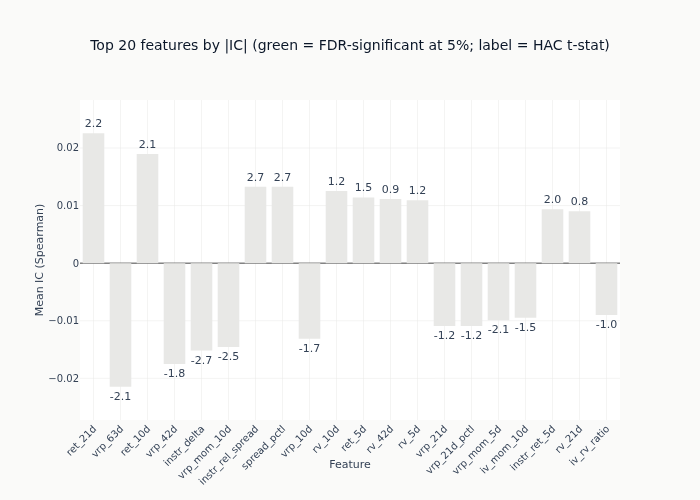

In [40]:
top_20 = eval_summary.sort(pl.col("ic_mean").abs(), descending=True).head(20)

colors = [
    COLORS["positive"] if sig else COLORS["silver_muted"]
    for sig in top_20["significant_fdr05"].to_list()
]
fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=top_20["feature"].to_list(),
        y=top_20["ic_mean"].to_list(),
        marker_color=colors,
        text=[f"{t:.1f}" for t in top_20["hac_tstat"].to_list()],
        textposition="outside",
    )
)
fig.update_layout(
    title="Top 20 features by |IC| (green = FDR-significant at 5%; label = HAC t-stat)",
    xaxis_title="Feature",
    yaxis_title="Mean IC (Spearman)",
    template="ml4t",
    xaxis_tickangle=-45,
    height=500,
)
fig.show()

### Feature Correlation Heatmap

In [41]:
sample_dates = eval_df["timestamp"].unique().sort().to_list()
sample_dates = sample_dates[::3]  # Every 3rd date (small dataset)

corr_features = [c for c in valid_features if c in eval_df.columns]
corr_data = eval_df.filter(pl.col("timestamp").is_in(sample_dates)).select(corr_features)
corr_matrix = corr_data.to_pandas().corr(method="spearman")

high_corr_pairs = []
for i, f1 in enumerate(corr_matrix.columns):
    for j, f2 in enumerate(corr_matrix.columns):
        if i < j and abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((f1, f2, float(corr_matrix.iloc[i, j])))

display_features = [
    name for name in eval_summary.sort(pl.col("ic_mean").abs(), descending=True)["feature"][:24]
]
display_corr = corr_matrix.loc[display_features, display_features]
display_pairs = sum(
    abs(display_corr.iloc[i, j]) > 0.7
    for i in range(len(display_corr.columns))
    for j in range(i + 1, len(display_corr.columns))
)

Render the highest-IC subset on the canonical negative-neutral-positive scale.

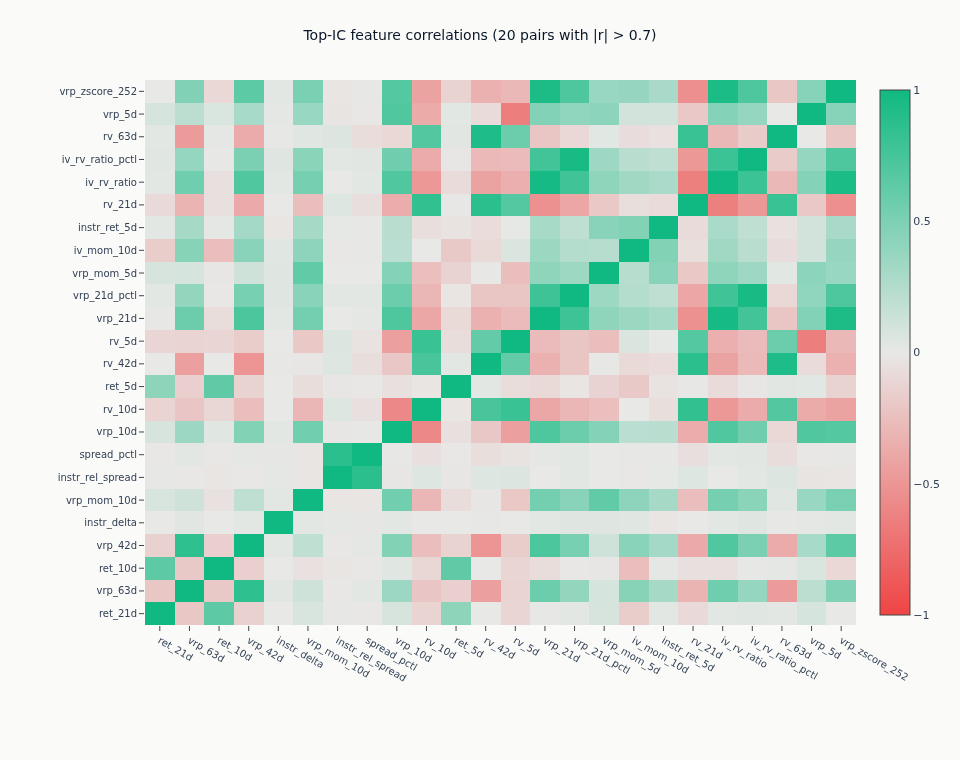

In [42]:
fig = go.Figure(
    data=go.Heatmap(
        z=display_corr.values,
        x=display_corr.columns.tolist(),
        y=display_corr.columns.tolist(),
        colorscale=ml4t_diverging(),
        zmid=0,
        zmin=-1,
        zmax=1,
    )
)
fig.update_layout(
    title=f"Top-IC feature correlations ({display_pairs} pairs with |r| > 0.7)",
    template="ml4t",
    height=760,
    width=960,
    margin=dict(l=145, r=60, t=80, b=135),
    yaxis=dict(automargin=True),
    xaxis=dict(automargin=True),
)
fig.show()

The full-matrix pair count identifies redundancy beyond the displayed subset.

In [43]:
print(f"\nHigh-correlation pairs (|r| > 0.7): {len(high_corr_pairs)}")
for f1, f2, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2]))[:10]:
    print(f"  {f1} <-> {f2}: {r:.3f}")


High-correlation pairs (|r| > 0.7): 70
  instr_dte <-> dte_normalized: 1.000
  instr_mid <-> instr_ask: 0.999
  instr_gamma <-> instr_mid: -0.999
  instr_mid <-> instr_bid: 0.999
  instr_gamma <-> instr_ask: -0.999
  instr_gamma <-> instr_bid: -0.998
  iv_atm <-> put_iv: 0.998
  iv_atm <-> call_iv: 0.998
  instr_bid <-> instr_ask: 0.997
  call_iv <-> put_iv: 0.994


### Naive vs HAC t-statistics

In [44]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=eval_summary["naive_tstat"].to_list(),
        y=eval_summary["hac_tstat"].to_list(),
        mode="markers",
        text=eval_summary["feature"].to_list(),
        marker=dict(
            color=[
                COLORS["positive"] if s else COLORS["neutral"]
                for s in eval_summary["significant_fdr05"].to_list()
            ],
            size=8,
        ),
        showlegend=False,
    )
)
deflation_ratios = eval_summary.with_columns(
    (pl.col("naive_tstat").abs() / pl.col("hac_tstat").abs().clip(lower_bound=0.01)).alias("ratio")
)
median_deflation = float(deflation_ratios["ratio"].median())

The identity line shows where HAC leaves a statistic unchanged; the median summarizes the shift.

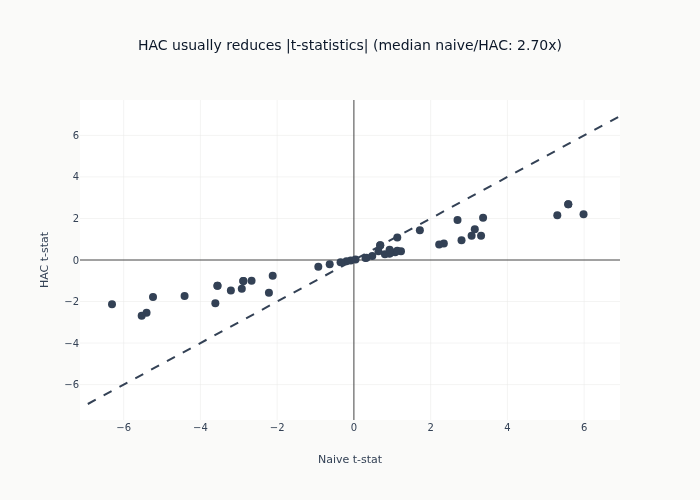

Median naive/HAC |t-stat| ratio: 2.70x


In [45]:
naive_max = float(eval_summary["naive_tstat"].abs().max())
hac_max = float(eval_summary["hac_tstat"].abs().max())
max_t = max(naive_max, hac_max, 1.0) * 1.1
fig.add_trace(
    go.Scatter(
        x=[-max_t, max_t],
        y=[-max_t, max_t],
        mode="lines",
        line=dict(dash="dash", color=COLORS["neutral"]),
        showlegend=False,
    )
)
fig.update_layout(
    title=f"HAC usually reduces |t-statistics| (median naive/HAC: {median_deflation:.2f}x)",
    xaxis_title="Naive t-stat",
    yaxis_title="HAC t-stat",
    template="ml4t",
    height=500,
)
fig.show()
print(f"Median naive/HAC |t-stat| ratio: {median_deflation:.2f}x")

**Interpretation**:

The HAC adjustment is essential for this case study: the primary hold-to-expiry
label overlaps for about 21 trading sessions, while the secondary diagnostic
spans 10. Consecutive IC observations are therefore autocorrelated, inflating
naive t-statistics. The FDR correction further filters multiple tests.

No individual feature survives BH-FDR after the HAC bandwidth is matched to
the hold-to-expiry overlap. The largest positive mean IC, 0.0226 for 21-day
momentum, has a HAC t-statistic of 2.20 but an adjusted p-value of 0.22. This
rules out a standalone discovery claim; multivariate models still test whether
weak features combine into useful cross-sectional forecasts.

The delta-hedged label comparison reveals whether features predict directional
movement (high unhedged IC, low hedged IC) or pure volatility (similar IC for
both). Features with high hedged IC are the most valuable for a short vol strategy.

In [46]:
# Build evaluation block for results JSON
evaluation_block = {
    "primary_label": _label_col,
    "n_features_tested": len(feature_names),
    "n_significant_naive05": n_naive_sig,
    "n_significant_fdr05": n_significant,
    "naive_to_fdr_count_ratio": round(inflation_factor, 1)
    if inflation_factor is not None
    else None,
    "primary_hac_horizon_trading_days": PRIMARY_HAC_HORIZON,
    "secondary_hac_horizon_trading_days": SECONDARY_HAC_HORIZON,
    "top_features": [
        {
            "name": row["feature"],
            "ic_mean": round(row["ic_mean"], 4),
            "hac_tstat": round(row["hac_tstat"], 2),
            "hac_pval": round(row["p_value"], 4),
        }
        for row in eval_summary.head(10).to_dicts()
    ],
    "max_pairwise_corr": round(max(abs(c) for _, _, c in high_corr_pairs), 3)
    if high_corr_pairs
    else 0.0,
    "corr_pairs_above_07": len(high_corr_pairs),
    "feature_family_avg_ic": {
        k: round(v, 4) for k, v in sorted(family_avg_ic.items(), key=lambda x: -abs(x[1]))
    },
}

## 11. Results Collection

In [47]:
def _git_commit_hash():
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "--short", "HEAD"], text=True, timeout=5
        ).strip()
    except Exception:
        return "unknown"

Derive the feature count from the final public table and verify it against the category totals.

In [48]:
feature_family_counts = {
    "instrument_state": sum(1 for c in instrument_cols if c in feature_table.columns),
    "surface": sum(1 for c in surface_cols if c in feature_table.columns),
    "vrp": sum(1 for c in vrp_cols if c in feature_table.columns),
    "realized_vol": sum(1 for c in rv_cols if c in feature_table.columns),
    "cross_sectional": sum(1 for c in rank_cols if c in feature_table.columns),
    "underlying": sum(1 for c in underlying_cols if c in feature_table.columns),
    "quality": sum(1 for c in quality_cols if c in feature_table.columns),
}
public_id_cols = ["timestamp", "symbol", "instrument_id"]
model_feature_cols = [
    c for c in feature_table.columns if c not in public_id_cols and c not in meta_cols
]
n_features = len(model_feature_cols)
if n_features != sum(feature_family_counts.values()):
    raise ValueError("Public feature count does not match the feature-family total")

results = {
    "case_study_id": STRATEGY_ID,
    "chapter": 8,
    "stage": "features",
    "timestamp": datetime.now(UTC).isoformat(),
    "git_commit": _git_commit_hash(),
    "notebook": f"case_studies/{STRATEGY_ID}/03_financial_features.py",
    "summary": {
        "n_observations": len(feature_table),
        "n_features": n_features,
        "n_symbols": feature_table["symbol"].n_unique(),
        "date_range": [
            str(feature_table["timestamp"].min()),
            str(feature_table["timestamp"].max()),
        ],
        "feature_families": feature_family_counts,
    },
}

Complete the record with methods, diagnostics, findings, and the inference block.

In [49]:
results.update(
    {
        "techniques": {
            "instrument_features": "straddle mid, Greeks, DTE, relative spread",
            "vrp_features": "IV-RV spread at 5/10/21/42/63d and trailing 252d z-score",
            "dynamics": "IV momentum (5/10/21d), VRP momentum (5/10d)",
            "cross_sectional": "percentile ranks for VRP, IV, spread, IV-RV ratio",
        },
        "diagnostics": {
            "vrp_mean_pre_holdout": float(baseline_features["vrp_21d"].mean()),
            "vrp_std_pre_holdout": float(baseline_features["vrp_21d"].std()),
            "null_fraction": float(
                feature_table.null_count().sum_horizontal().item()
                / (len(feature_table) * len(feature_table.columns))
            ),
        },
        "key_findings": [
            f"Feature matrix: {len(feature_table):,} rows x {n_features} features",
            f"Pre-holdout VRP(21d) mean: {float(baseline_features['vrp_21d'].mean()):.4f}",
            "Instrument state features separate from surface features",
            "VRP z-score (252d) captures the regime-adjusted VRP level",
        ],
    }
)

results["evaluation"] = evaluation_block
print(f"Results metadata: {n_features} model features across 7 categories")

Results metadata: 47 model features across 7 categories


## Key Takeaways

1. **Instrument vs surface features**: Instrument features (straddle mid,
   Greeks, DTE, spread) describe what we trade; surface features (IV, skew,
   VRP) describe the volatility environment. Keeping them separate aids
   interpretability.

2. **VRP z-score (252d)**: Normalizing VRP by its own history removes
   the level effect -- a VRP of 5% means different things in calm vs
   stressed regimes. The trailing z-score captures this regime context.

3. **Cross-sectional ranks**: Ranking VRP and IV within each date's universe
   produces stationary features that work well for cross-sectional selection
   (which straddles to sell vs avoid).

4. **Quality as control**: Convergence quality features should not predict
   returns, but unreliable IV observations can introduce noise.

5. **Inference changes the verdict**: Nine features look significant under
   naive errors, but none survives horizon-aware HAC plus BH-FDR. Individual
   feature ICs are diagnostics, not standalone discoveries.

**Next**: [`04_model_based_features`](04_model_based_features.ipynb) adds GARCH and Bayesian SV temporal features.